In [2]:
2+1

3

In [3]:
from research_analysis_generation.logger.custom_logger import CustomLogger

logger = CustomLogger().get_logger()
logger.info("upload")

{"timestamp": "2026-05-17T14:33:18.348491Z", "level": "info", "event": "upload"}


In [4]:
from typing import TypedDict, List
from pydantic import Field, BaseModel

In [5]:
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage

In [6]:
class Analyst(BaseModel):
    name: str = Field(description="name of the analyst")
    role: str = Field(description="role of the analyst")
    Description: str = Field(description="description of the role")
    
    @property
    def persona(self) -> str:
        return f"Name: {self.name} \n Role: {self.role} \n Description: {self.Description}"

In [8]:
analyst = Analyst(
    name="Megha U",
    role="AI Engineer",
    Description=""
)

In [9]:
print(analyst)

name='Megha U' role='AI Engineer' Description=''


In [10]:
analyst.persona

'Name: Megha U \n Role: AI Engineer \n Description: '

In [11]:
analyst.name

'Megha U'

In [12]:
class Perspective(BaseModel):
    analysts: List[Analyst] = Field(description="list of analysts")

In [13]:
class GenerateState(TypedDict):
    topic: str
    max_analyst: int 
    human_feedback: str 
    analysts: List[Analyst] 

In [14]:
analyst_instructions="""You are tasked with creating a set of AI analyst personas. Follow these instructions carefully:

1. First, review the research topic:
{topic}
        
2. Examine any editorial feedback that has been optionally provided to guide creation of the analysts: 
        
{human_feedback}
    
3. Determine the most interesting themes based upon documents and / or feedback above.
                    
4. Pick the top {max_analyst} themes.

5. Assign one analyst to each theme."""

In [15]:
from research_analysis_generation.utils.model_loader import ModelLoader

model_loader = ModelLoader()
llm = model_loader.load_llm()

{"timestamp": "2026-05-17T14:34:07.306767Z", "level": "info", "event": "Initializing ApiKeyManager"}
{"timestamp": "2026-05-17T14:34:07.307481Z", "level": "info", "event": "OPENAI_API_KEY loaded successfully from environment"}
{"timestamp": "2026-05-17T14:34:07.307809Z", "level": "info", "event": "GROQ_API_KEY loaded successfully from environment"}
{"timestamp": "2026-05-17T14:34:07.308289Z", "level": "info", "event": "TAVILY_API_KEY loaded successfully from environment"}
{"config_keys": ["embedding_model", "llm", "retriever", "chunking"], "timestamp": "2026-05-17T14:34:07.311276Z", "level": "info", "event": "YAML configuration loaded successfully"}
{"provider": "openai", "model": "gpt-4o-mini", "timestamp": "2026-05-17T14:34:07.311747Z", "level": "info", "event": "Loading LLM"}
{"provider": "openai", "model": "gpt-4o-mini", "timestamp": "2026-05-17T14:34:07.538908Z", "level": "info", "event": "LLM loaded successfully"}


In [16]:
llm.invoke("hi").content

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


'Hello! How can I assist you today?'

In [19]:
def create_analyst(state:GenerateState):
    topic = state.get("topic")
    max_analyst = state.get("max_analyst")
    human_feedback = state.get("human_feedback")
    
    structured_llm = llm.with_structured_output(Perspective)
      
    system_message = analyst_instructions.format(
        topic = topic,
        max_analyst = max_analyst,
        human_feedback = human_feedback
    )
    
    analysts = structured_llm.invoke([SystemMessage(content=system_message)] + [HumanMessage(content="Generate the set of analysts.")])
    
    return {"analysts": analysts.analysts}

In [20]:
create_analyst(
    {
        'topic': 'health',
        'max_analysts': 1,
        'human_analyst_feedback': 'give the real info'}
    )


HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


{'analysts': [Analyst(name='Dr. Emily Carter', role='Public Health Analyst', Description='Dr. Emily Carter specializes in analyzing public health data to identify trends and inform policy decisions. Her focus is on disease prevention and health promotion strategies.'),
  Analyst(name='James Liu', role='Healthcare Technology Analyst', Description='James Liu examines the impact of technology on healthcare delivery, including telemedicine, electronic health records, and health informatics. He evaluates how these innovations improve patient outcomes.'),
  Analyst(name='Sarah Thompson', role='Mental Health Analyst', Description='Sarah Thompson focuses on mental health trends, analyzing data related to mental health disorders, treatment efficacy, and the social determinants of mental health.'),
  Analyst(name='Dr. Michael Patel', role='Epidemiologist', Description='Dr. Michael Patel studies the distribution and determinants of health-related states in populations. He conducts research on inf

In [21]:
def human_feedback(state: GenerateState):
    """No interruption"""
    pass

In [22]:
from langgraph.graph import START, END, StateGraph

In [23]:
def should_continue(state: GenerateState):
    feedback = (state.get("human_feedback") or "").strip().lower()
    
    if feedback and feedback not in ["", "none", "skip", "done", "continue"]:
        return "create_analyst"
    return END

In [24]:
state_graph = StateGraph(GenerateState)
state_graph.add_node("create_analyst", create_analyst)
state_graph.add_node("human_feedback", human_feedback)

state_graph.add_edge(START, "create_analyst")
state_graph.add_edge("create_analyst", "human_feedback")

state_graph.add_conditional_edges("human_feedback",
                                  should_continue,
                                  ["create_analyst", END])

In [25]:
from langgraph.checkpoint.memory import MemorySaver

In [26]:
memory = MemorySaver()
graph = state_graph.compile(interrupt_before=["human_feedback"], checkpointer=memory)

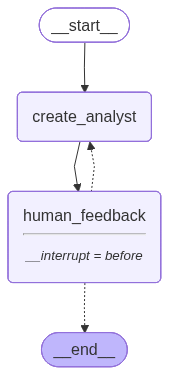

In [27]:
from IPython.display import Image, display

display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [28]:
topic = "the benefits of adopting Langgraph as an agent framework"
max_analyst = 3
thread = {
    "configurable": {
        "thread_id":1
    }
}

In [29]:
for event in graph.stream(
    {
        "topic":topic,
        "max_analysts":max_analyst
    },
    thread,
    stream_mode= "values"):
    
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print("\n")
    

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Chen
Role: AI Framework Specialist


Name: Mark Thompson
Role: Business Analyst


Name: Sarah Patel
Role: User Experience Researcher


Name: James O'Connor
Role: Data Scientist


Name: Linda Martinez
Role: Ethics and Compliance Advisor




In [30]:
state = graph.get_state(thread)

In [31]:
state

StateSnapshot(values={'topic': 'the benefits of adopting Langgraph as an agent framework', 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Specialist', Description='Dr. Chen focuses on the technical advantages of Langgraph, analyzing its architecture and performance metrics compared to other agent frameworks.'), Analyst(name='Mark Thompson', role='Business Analyst', Description='Mark evaluates the business implications of adopting Langgraph, including cost-benefit analysis and potential ROI for organizations.'), Analyst(name='Sarah Patel', role='User Experience Researcher', Description='Sarah investigates how Langgraph enhances user experience for developers and end-users, emphasizing usability and integration.'), Analyst(name="James O'Connor", role='Data Scientist', Description='James explores the data handling capabilities of Langgraph, assessing its efficiency in processing and analyzing large datasets.'), Analyst(name='Linda Martinez', role='Ethics and Compliance Adv

In [32]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Specialist', Description='Dr. Chen focuses on the technical advantages of Langgraph, analyzing its architecture and performance metrics compared to other agent frameworks.'),
  Analyst(name='Mark Thompson', role='Business Analyst', Description='Mark evaluates the business implications of adopting Langgraph, including cost-benefit analysis and potential ROI for organizations.'),
  Analyst(name='Sarah Patel', role='User Experience Researcher', Description='Sarah investigates how Langgraph enhances user experience for developers and end-users, emphasizing usability and integration.'),
  Analyst(name="James O'Connor", role='Data Scientist', Description='James explores the data handling capabilities of Langgraph, assessing its efficiency in processing and analyzing large datasets.'),
  Analyst(name='Linda Martinez', role='Ethics and Compliance Advisor', Descr

In [33]:
state.next

('human_feedback',)

In [34]:
memory.storage.items()

dict_items([('1', defaultdict(<class 'dict'>, {'': {'1f151fd9-1808-6bde-bfff-cdde1fb15e51': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-05-17T14:34:53.489239+00:00\xa2id\xd9$1f151fd9-1808-6bde-bfff-cdde1fb15e51\xb0channel_versions\x81\xa9__start__\xd9300000000000000000000000000000001.0.7939587793092591\xadversions_seen\x81\xa9__input__\x80\xb0updated_channels\x91\xa9__start__'), ('msgpack', b'\x83\xa6source\xa5input\xa4step\xff\xa7parents\x80'), None), '1f151fd9-1814-62cc-8000-ae3478affac1': (('msgpack', b'\x86\xa1v\x04\xa2ts\xd9 2026-05-17T14:34:53.493912+00:00\xa2id\xd9$1f151fd9-1814-62cc-8000-ae3478affac1\xb0channel_versions\x83\xa9__start__\xd9300000000000000000000000000000002.0.7065851066121256\xa5topic\xd9300000000000000000000000000000002.0.7065851066121256\xb8branch:to:create_analyst\xd9300000000000000000000000000000002.0.7065851066121256\xadversions_seen\x82\xa9__input__\x80\xa9__start__\x81\xa9__start__\xd9300000000000000000000000000000001.0.7939587793092591\xb0updated_channel

In [35]:
state.config

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f151fd9-487b-6316-8001-72a21fcb143f'}}

In [36]:
graph.update_state(thread,
                   {"human_analyst_feedback":"add something from the startup perspective and focus on the latest enterprise application"},as_node="human_feedback"
                   )

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f151fd9-e876-6988-8002-f73892451edf'}}

In [38]:
for event in graph.stream(
    {
        "topic":topic,
        "max_analysts":max_analyst
    },
    thread,
    stream_mode= "values"):
    
    analysts = event.get('analysts', '')
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"Role: {analyst.role}")
            print(f"Description: {analyst.Description}")
            print("\n")

Name: Dr. Emily Chen
Role: AI Framework Specialist
Description: Dr. Chen focuses on the technical advantages of Langgraph, analyzing its architecture and performance metrics compared to other agent frameworks.


Name: Mark Thompson
Role: Business Analyst
Description: Mark evaluates the business implications of adopting Langgraph, including cost-benefit analysis and potential ROI for organizations.


Name: Sarah Patel
Role: User Experience Researcher
Description: Sarah investigates how Langgraph enhances user experience for developers and end-users, emphasizing usability and integration.


Name: James O'Connor
Role: Data Scientist
Description: James explores the data handling capabilities of Langgraph, assessing its efficiency in processing and analyzing large datasets.


Name: Linda Martinez
Role: Ethics and Compliance Advisor
Description: Linda examines the ethical considerations and compliance aspects of using Langgraph, ensuring it aligns with industry standards and regulations.




HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Chen
Role: AI Framework Specialist
Description: Dr. Chen focuses on the technical advantages of adopting Langgraph, analyzing its architecture and performance metrics compared to other frameworks.


Name: Mark Thompson
Role: Business Analyst
Description: Mark evaluates the business implications of implementing Langgraph, including cost-benefit analysis and potential ROI for organizations.


Name: Sarah Patel
Role: User Experience Researcher
Description: Sarah investigates how Langgraph enhances user experience for developers and end-users, emphasizing usability and accessibility.


Name: James O'Connor
Role: Data Scientist
Description: James explores the data handling capabilities of Langgraph, assessing its efficiency in processing and analyzing large datasets.


Name: Linda Martinez
Role: Industry Trends Analyst
Description: Linda examines the broader industry trends related to agent frameworks, positioning Langgraph within the competitive landscape.




In [39]:
state.next

('human_feedback',)

In [40]:
state.values

{'topic': 'the benefits of adopting Langgraph as an agent framework',
 'analysts': [Analyst(name='Dr. Emily Chen', role='AI Framework Specialist', Description='Dr. Chen focuses on the technical advantages of Langgraph, analyzing its architecture and performance metrics compared to other agent frameworks.'),
  Analyst(name='Mark Thompson', role='Business Analyst', Description='Mark evaluates the business implications of adopting Langgraph, including cost-benefit analysis and potential ROI for organizations.'),
  Analyst(name='Sarah Patel', role='User Experience Researcher', Description='Sarah investigates how Langgraph enhances user experience for developers and end-users, emphasizing usability and integration.'),
  Analyst(name="James O'Connor", role='Data Scientist', Description='James explores the data handling capabilities of Langgraph, assessing its efficiency in processing and analyzing large datasets.'),
  Analyst(name='Linda Martinez', role='Ethics and Compliance Advisor', Descr

## Second Workflow

In [41]:
#Search web give information form this Tavily
import os
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

load_dotenv()
tavily_api_key = os.getenv("TAVILY_API_KEY")
tavily_search = TavilySearchResults()

/var/folders/7r/d2spyn4922q1khslr32024740000gn/T/ipykernel_17953/3554326.py:8: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults()


In [42]:
tavily_search.invoke("langchain")

[{'title': 'LangChain - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/LangChain',
  'content': '🦜️🔗, the parrot and chain emojis\n\nLangChain is a software framework that helps facilitate the integration of large language models (LLMs) into applications. As a language model integration framework, LangChain\'s use-cases largely overlap with those of language models in general, including document analysis and summarization, chatbots, and code analysis.\n\n## History\n\nLangChain was launched in October 2022 as an open source project by Harrison Chase, while working at machine learning startup Robust Intelligence. In April 2023, LangChain had incorporated and the new startup raised over $20 million in funding at a valuation of at least $200 million from venture firm Sequoia Capital, a week after announcing a $10 million seed investment from Benchmark "Benchmark (venture capital firm)"). [...] ## Capabilities\n\nLangChain\'s developers highlight the framework\'s applicability to use-

In [44]:
from typing import Annotated
import operator
from langgraph.graph import MessagesState

#create pydantic model
class InterviewState(MessagesState):
    max_num_turns:int 
    context: Annotated[list, operator.add]
    analyst: Analyst
    interview_transcript: str
    sections: list
    
class SearchQuery(BaseModel):
    search_query: str = Field(None, description="search query for retrieval.")

In [46]:
question_instustion = """You are an analyst tasked with interviewing an expert to learn about a specific topic. 

Your goal is boil down to interesting and specific insights related to your topic.

1. Interesting: Insights that people will find surprising or non-obvious.
        
2. Specific: Insights that avoid generalities and include specific examples from the expert.

Here is your topic of focus and set of goals: {goals}
        
Begin by introducing yourself using a name that fits your persona, and then ask your question.

Continue to ask questions to drill down and refine your understanding of the topic.
        
When you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"

Remember to stay in character throughout your response, reflecting the persona and goals provided to you."""

In [48]:
question_instustion.format(goals=analyst)

'You are an analyst tasked with interviewing an expert to learn about a specific topic. \n\nYour goal is boil down to interesting and specific insights related to your topic.\n\n1. Interesting: Insights that people will find surprising or non-obvious.\n\n2. Specific: Insights that avoid generalities and include specific examples from the expert.\n\nHere is your topic of focus and set of goals: name=\'Linda Martinez\' role=\'Industry Trends Analyst\' Description=\'Linda examines the broader industry trends related to agent frameworks, positioning Langgraph within the competitive landscape.\'\n\nBegin by introducing yourself using a name that fits your persona, and then ask your question.\n\nContinue to ask questions to drill down and refine your understanding of the topic.\n\nWhen you are satisfied with your understanding, complete the interview with: "Thank you so much for your help!"\n\nRemember to stay in character throughout your response, reflecting the persona and goals provided t

In [47]:
def generate_question(state: InterviewState):
    """Node to generate question"""
    analyst = state["analyst"]
    messages = state["messages"]
    
    system_message = question_instustion.format(goals=analyst)
    
    question = llm.invoke([SystemMessage(content=system_message)]+messages)
    
    return {"messages": [question]}

In [49]:
from langchain_core.messages import get_buffer_string

search_instructions = SystemMessage(content=f"""You will be given a conversation between an analyst and an expert. 
Your goal is to generate a well-structured query for use in retrieval and / or web-search related to the conversation. 
First, analyze the full conversation.
Pay particular attention to the final question posed by the analyst.
Convert this final question into a well-structured web search query""")


In [50]:
def search_web(state: InterviewState):
    """
    Fetch data from the web
    """
    
    str_llm = llm.with_structured_output(SearchQuery)
    search_query = str_llm.invoke([search_instructions]+state["messages"])
    
    searched_docs = tavily_search.invoke(search_query.search_query)
    
    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document href="{doc["url"]}"/>\n{doc["content"]}\n</Document>'
            for doc in searched_docs
        ]
    )

    return {"context": [formatted_search_docs]}
    

In [51]:

def search_wikipedia(state:InterviewState):
    """
    Retrieve data from wiki
    """
    structured_llm = llm.with_structured_output(SearchQuery)
    search_query = structured_llm.invoke([search_instructions]+state['messages'])
    
    print("*******************************")
    print(search_query)
    
    search_docs = WikipediaLoader(query=search_query.search_query).load()

    formatted_search_docs = "\n\n---\n\n".join(
        [
            f'<Document source="{doc.metadata["source"]}" page="{doc.metadata.get("page", "")}"/>\n{doc.page_content}\n</Document>'
            for doc in search_docs
        ]
    )

    return {"context": [formatted_search_docs]} 


In [52]:
answer_instructions = """You are an expert being interviewed by an analyst.

Here is analyst area of focus: {goals}. 
        
You goal is to answer a question posed by the interviewer.

To answer question, use this context:
        
{context}

When answering questions, follow these guidelines:
        
1. Use only the information provided in the context. 
        
2. Do not introduce external information or make assumptions beyond what is explicitly stated in the context.

3. The context contain sources at the topic of each individual document.

4. Include these sources your answer next to any relevant statements. For example, for source # 1 use [1]. 

5. List your sources in order at the bottom of your answer. [1] Source 1, [2] Source 2, etc
        
6. If the source is: <Document source="assistant/docs/llama3_1.pdf" page="7"/>' then just list: 
        
[1] assistant/docs/llama3_1.pdf, page 7 
        
And skip the addition of the brackets as well as the Document source preamble in your citation."""


In [53]:
def generate_answer(state:InterviewState):
    
    """ Node to answer a question """
   
    analyst = state["analyst"]
    messages = state["messages"]
    context = state["context"]

    system_message = answer_instructions.format(goals=analyst.persona, context=context)
    answer = llm.invoke([SystemMessage(content=system_message)]+messages)
            
    answer.name = "expert"
    
    return {"messages": [answer]}

In [54]:
def save_answer(state: InterviewState):
    """ Save interviews """

    messages = state["messages"]
    interview = get_buffer_string(messages)
    
    return {"interview": interview}

In [56]:
section_writer_instructions = """You are an expert technical writer. 
            
Your task is to create a short, easily digestible section of a report based on a set of source documents.

1. Analyze the content of the source documents: 
- The name of each source document is at the start of the document, with the <Document tag.
        
2. Create a report structure using markdown formatting:
- Use ## for the section title
- Use ### for sub-section headers
        
3. Write the report following this structure:
a. Title (## header)
b. Summary (### header)
c. Sources (### header)

4. Make your title engaging based upon the focus area of the analyst: 
{focus}

5. For the summary section:
- Set up summary with general background / context related to the focus area of the analyst
- Emphasize what is novel, interesting, or surprising about insights gathered from the interview
- Create a numbered list of source documents, as you use them
- Do not mention the names of interviewers or experts
- Aim for approximately 400 words maximum
- Use numbered sources in your report (e.g., [1], [2]) based on information from source documents
        
6. In the Sources section:
- Include all sources used in your report
- Provide full links to relevant websites or specific document paths
- Separate each source by a newline. Use two spaces at the end of each line to create a newline in Markdown.
- It will look like:

### Sources
[1] Link or Document name
[2] Link or Document name

7. Be sure to combine sources. For example this is not correct:

[3] https://ai.meta.com/blog/meta-llama-3-1/
[4] https://ai.meta.com/blog/meta-llama-3-1/

There should be no redundant sources. It should simply be:

[3] https://ai.meta.com/blog/meta-llama-3-1/
        
8. Final review:
- Ensure the report follows the required structure
- Include no preamble before the title of the report
- Check that all guidelines have been followed"""

In [57]:
def write(state: InterviewState):
    """ Node to answer a question """
    interview = state["interview"]
    context = state["context"]
    analyst = state["analyst"]
   
    system_message = section_writer_instructions.format(focus=analyst.description)
    section = llm.invoke([SystemMessage(content=system_message)]+[HumanMessage(content=f"Use this source to write your section: {context}")]) 
                
    return {"sections": [section.content]}

In [58]:
def route_messages(state: InterviewState, name: str = "expert"):
    """ Route between question and answer """
    
    messages = state["messages"]
    max_num_turns = state.get('max_num_turns', 2)

    num_responses = len(
        [m for m in messages if isinstance(m, AIMessage) and m.name == name]
    )

    if num_responses >= max_num_turns:
        return 'save_answer'

    last_question = messages[-2]
    
    if "Thank you so much for your help" in last_question.content:
        return 'save_answer'
    
    return "ask_question"

In [59]:
builder = StateGraph(InterviewState)
builder.add_node("generate_question", generate_question)
builder.add_node("search_web", search_web)
builder.add_node("search_wikipedia", search_wikipedia)
builder.add_node("generate_answer", generate_answer)
builder.add_node("save_data", save_answer)
builder.add_node("write_section", write)

builder.add_edge(START, "generate_question")
builder.add_edge("generate_question", "search_web")
builder.add_edge("generate_question", "search_wikipedia")
builder.add_edge("search_web", "generate_answer")
builder.add_edge("search_wikipedia", "generate_answer")
builder.add_conditional_edges("generate_answer", route_messages, ["generate_question", "save_data"])
builder.add_edge("save_data", "write_section")
builder.add_edge("write_section", END)

In [60]:
graph_builder = builder.compile(checkpointer=memory).with_config(run_name = "Conduct Interview")

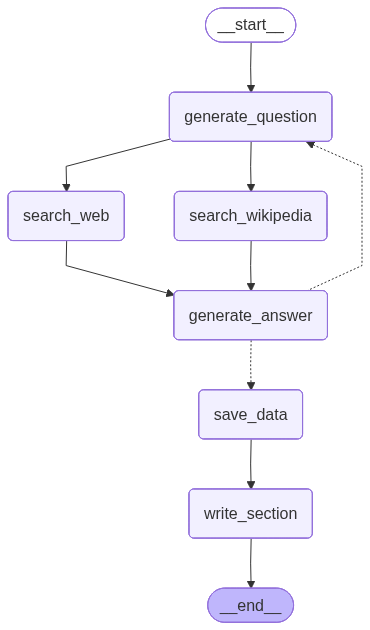

In [61]:
from IPython.display import Image, display

display(Image(graph_builder.get_graph(xray=1).draw_mermaid_png()))

In [62]:
state = {"max_num_turns":2,
         "context":[],
         "analyst":analyst,
         "interview":"","section":[],
         "messages":[HumanMessage(content="hi do the proper search according to the experties")]}

In [64]:
for message in result.get("messages"):
    print(message)
    print("\n")


content="Hello, my name is Alex Carter, and I'm an industry analyst focused on emerging technologies. I'm excited to speak with you today, Linda, to gain insights into the current trends in agent frameworks and how Langgraph is positioning itself in the competitive landscape. \n\nTo start, could you share some surprising trends you've observed in the development of agent frameworks over the past year? What are some specific examples that illustrate these trends?" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 201, 'total_tokens': 284, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b3f4b08c22', 'id': 'chatcmpl-DgWuARLjjxLsiwCF7k4e0SLXd74EZ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprob

In [65]:
result["messages"][0].content

"Hello, my name is Alex Carter, and I'm an industry analyst focused on emerging technologies. I'm excited to speak with you today, Linda, to gain insights into the current trends in agent frameworks and how Langgraph is positioning itself in the competitive landscape. \n\nTo start, could you share some surprising trends you've observed in the development of agent frameworks over the past year? What are some specific examples that illustrate these trends?"

In [66]:
result = search_web(state)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


In [67]:
print(result.get("context")[0])

<Document href="https://www.fluviomarketing.com/blog-summary/market-research-best-practices-how-to-run-smarter-faster-more-actionable-studies"/>
## Best practices for effective research

Research only works when it’s structured for quality and relevance. Our top best practices include: [...] ## Introduction

Market research is the backbone of successful B2B SaaS strategy. Whether you're exploring new pricing models, testing messaging, or informing product development, research grounds your decisions in real customer insight. Yet many companies struggle with inconsistent research practices, vague objectives, or unusable data. This article breaks down how to run smarter, faster, and more actionable market research—drawing on proven best practices and Fluvio’s own approach, including the secret weapon we always use: the research prospectus.

## Why market research matters

Done right, market research becomes your early-warning system and strategy accelerator. In B2B SaaS, it: [...] Messag

## Third Workflpw

In [68]:
from langgraph.types import Send

In [69]:
class ResearchGraphState(TypedDict):
    topic: str
    max_analyst: int
    human_analyst_feedback: str
    analysts: List[Analyst]
    sections: Annotated[list, operator.add]
    introduction: str
    content: str
    conclusion: str
    final_report: str 

In [71]:
def initiate_all_interviews(state:ResearchGraphState):
    """ This is the "map" step where we run each interview sub-graph using Send API """ 
    
    #check if human feedback
    human_analyst_feedback=state.get('human_analyst_feedback')
    if human_analyst_feedback:
        # Return to create_analysts
        return "create_analysts"
    
    # Otherwise kick off interviews in parallel via Send() API
    else:
        topic = state["topic"]
        return [Send("conduct_interview", {"analyst": analyst,
                                        "messages": [HumanMessage(
                                            content=f"So you said you were writing an article on {topic}?"
                                        )
                                                ]}) for analyst in state["analysts"]]

In [72]:
intro_conclusion_instructions = """You are a technical writer finishing a report on {topic}

You will be given all of the sections of the report.

You job is to write a crisp and compelling introduction or conclusion section.

The user will instruct you whether to write the introduction or conclusion.

Include no pre-amble for either section.

Target around 100 words, crisply previewing (for introduction) or recapping (for conclusion) all of the sections of the report.

Use markdown formatting. 

For your introduction, create a compelling title and use the # header for the title.

For your introduction, use ## Introduction as the section header. 

For your conclusion, use ## Conclusion as the section header.

Here are the sections to reflect on for writing: {formatted_str_sections}"""

In [73]:
report_writer_instructions = """You are a technical writer creating a report on this overall topic: 

{topic}
    
You have a team of analysts. Each analyst has done two things: 

1. They conducted an interview with an expert on a specific sub-topic.
2. They write up their finding into a memo.

Your task: 

1. You will be given a collection of memos from your analysts.
2. Think carefully about the insights from each memo.
3. Consolidate these into a crisp overall summary that ties together the central ideas from all of the memos. 
4. Summarize the central points in each memo into a cohesive single narrative.

To format your report:
 
1. Use markdown formatting. 
2. Include no pre-amble for the report.
3. Use no sub-heading. 
4. Start your report with a single title header: ## Insights
5. Do not mention any analyst names in your report.
6. Preserve any citations in the memos, which will be annotated in brackets, for example [1] or [2].
7. Create a final, consolidated list of sources and add to a Sources section with the `## Sources` header.
8. List your sources in order and do not repeat.

[1] Source 1
[2] Source 2

Here are the memos from your analysts to build your report from: 

{context}"""

In [74]:
def write_intro(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    intro = llm.invoke([instructions] + [HumanMessage(content=f"Write the report introduction")]) 
    return {"introduction": intro.content}

In [75]:
def write_conclusion(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    
    instructions = intro_conclusion_instructions.format(topic=topic, formatted_str_sections=formatted_str_sections)    
    conclusion = llm.invoke([instructions]+[HumanMessage(content=f"Write the report conclusion")]) 
    return {"conclusion": conclusion.content}

In [76]:
def write_report(state: ResearchGraphState):
    # Full set of sections
    sections = state["sections"]
    topic = state["topic"]

    # Concat all sections together
    formatted_str_sections = "\n\n".join([f"{section}" for section in sections])
    
    # Summarize the sections into a final report
    system_message = report_writer_instructions.format(topic=topic, context=formatted_str_sections)    
    report = llm.invoke([SystemMessage(content=system_message)] + [HumanMessage(content=f"Write a report based upon these memos.")]) 
    return {"content": report.content}

In [77]:

def finalize_report(state: ResearchGraphState):
    """ The is the "reduce" step where we gather all the sections, combine them, and reflect on them to write the intro/conclusion """
    # Save full final report
    content = state["content"]
    if content.startswith("## Insights"):
        content = content.strip("## Insights")
    if "## Sources" in content:
        try:
            content, sources = content.split("\n## Sources\n")
        except:
            sources = None
    else:
        sources = None

    final_report = state["introduction"] + "\n\n---\n\n" + content + "\n\n---\n\n" + state["conclusion"]
    if sources is not None:
        final_report += "\n\n## Sources\n" + sources
    return {"final_report": final_report}

In [78]:
write_graph = StateGraph(ResearchGraphState)

write_graph.add_node("create_analyst", create_analyst)
write_graph.add_node("human_feedback", human_feedback)
write_graph.add_node("conduct_interview", builder.compile()) 
write_graph.add_node("write_intro", write_intro)
write_graph.add_node("write_conclusion", write_conclusion)
write_graph.add_node("write_report", write_report)
write_graph.add_node("finalize_report", finalize_report)

write_graph.add_edge(START, "create_analyst")
write_graph.add_edge("create_analyst", "human_feedback")

write_graph.add_conditional_edges(
    "human_feedback",
    initiate_all_interviews,
    ["create_analyst", "conduct_interview"]
)

write_graph.add_edge("conduct_interview", "write_report")
write_graph.add_edge("conduct_interview", "write_intro")
write_graph.add_edge("conduct_interview", "write_conclusion")

write_graph.add_edge("write_report", "finalize_report")
write_graph.add_edge("write_intro", "finalize_report")
write_graph.add_edge("write_conclusion", "finalize_report")

write_graph.add_edge("finalize_report", END)

In [79]:
memory = MemorySaver()

In [80]:

graph = write_graph.compile(interrupt_before=['human_feedback'], checkpointer=memory)

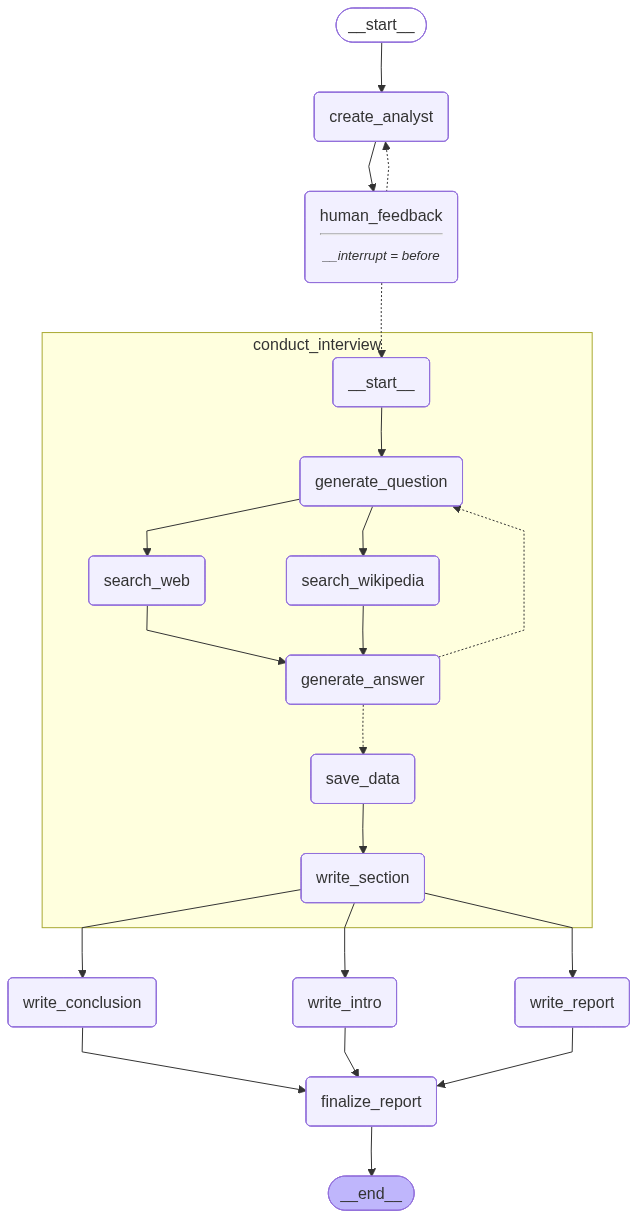

In [81]:
display(Image(graph.get_graph(xray=1).draw_mermaid_png()))

In [84]:
max_analyst

3

In [83]:
topic = "how can generative ai acceralate drug discovery?"

In [82]:
thread = {
    "configurable": { "thread_id" : "1"}}

In [85]:
for event in graph.stream({"topic": topic, "max_analyst": max_analyst}, thread, stream_mode="values"):
    analysts = event.get("analysts", "")
    
    if analysts:
        for analyst in analysts:
            print(f"Name: {analyst.name}")
            print(f"role: {analyst.role}")
            print("-"*50)

HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Name: Dr. Emily Carter
role: Computational Chemist
--------------------------------------------------
Name: Prof. James Liu
role: Data Scientist
--------------------------------------------------
Name: Sarah Thompson
role: Biotech Entrepreneur
--------------------------------------------------
